In [25]:
#Task3 
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import csv
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

In [26]:
#Task3 (a)
#NASDAQ100
df_NASDAQ100 = pd.read_csv('E1_NASDAQ100.csv')
df_NASDAQ100.set_index('Date', drop = True, inplace = True)

rd_ln_NASDAQ100 = np.log(df_NASDAQ100).diff().dropna()#log daily return
rd_ln_NASDAQ100.columns = ['LogReturn']
Vol_10d_NASDAQ100 = rd_ln_NASDAQ100['LogReturn'].rolling(window=21).std() #rolling volatility from 21 samples
Vol_10d_NASDAQ100 = np.sqrt(10) * Vol_10d_NASDAQ100.shift(1) #10days projection 
R_10d_ln_NASDAQ100 = pd.DataFrame(rd_ln_NASDAQ100['LogReturn'].rolling(window=10).sum()) #forward rolling 10 days log return
R_10d_ln_NASDAQ100 = R_10d_ln_NASDAQ100.shift(-9)
R_10d_ln_NASDAQ100.columns = ['Ret_10D']

z_99 = stats.norm.ppf(0.01, loc=0, scale=1)

VaR_10d_99_NASDAQ100 =  pd.DataFrame(z_99 * Vol_10d_NASDAQ100)
VaR_10d_99_NASDAQ100.columns = ['VaR_10D']

R_vs_VaR_NASDAQ100 = (R_10d_ln_NASDAQ100.dropna()).join(VaR_10d_99_NASDAQ100.dropna(), how = 'inner')

RvsVaR_NASDAQ100 = R_vs_VaR_NASDAQ100['Ret_10D'].lt(R_vs_VaR_NASDAQ100['VaR_10D'])
breach_NASDAQ100 = RvsVaR_NASDAQ100[RvsVaR_NASDAQ100 == True]
                  
count_breach_NASDAQ100 = len(breach_NASDAQ100)
PCT_breach_NASDAQ100 = count_breach_NASDAQ100/len(RvsVaR_NASDAQ100)
print(len(RvsVaR_NASDAQ100)) 
print(count_breach_NASDAQ100)
print(PCT_breach_NASDAQ100)


1642
43
0.026187576126674786


In [34]:
#SP500
df_SP500 = pd.read_csv('E1_SP500.csv')
df_SP500.set_index('Date', drop = True, inplace = True)

rd_ln_SP500 = np.log(df_SP500).diff().dropna()
rd_ln_SP500.columns = ['LogReturn']
Vol_10d_SP500 = rd_ln_SP500['LogReturn'].rolling(window=21).std()
Vol_10d_SP500 = np.sqrt(10) * Vol_10d_SP500.shift(1) 
R_10d_ln_SP500 = pd.DataFrame(rd_ln_SP500['LogReturn'].rolling(window=10).sum())
R_10d_ln_SP500 = R_10d_ln_SP500.shift(-9) 
R_10d_ln_SP500.columns = ['Ret_10D']

z_99 = stats.norm.ppf(0.01, loc=0, scale=1)

VaR_10d_99_SP500 = pd.DataFrame(z_99 * Vol_10d_SP500)
VaR_10d_99_SP500.columns = ['VaR_10D']

R_vs_VaR_SP500 = (R_10d_ln_SP500.dropna()).join(VaR_10d_99_SP500.dropna(), how = 'inner')

RvsVaR_SP500 = R_vs_VaR_SP500['Ret_10D'].lt(R_vs_VaR_SP500['VaR_10D'])
breach_SP500 = RvsVaR_SP500[RvsVaR_SP500 == True]

                 
count_breach_SP500 = len(breach_SP500)
PCT_breach_SP500 = count_breach_SP500/len(RvsVaR_SP500)
print(len(RvsVaR_SP500)) 
print(count_breach_SP500)
print(PCT_breach_SP500)

1642
61
0.03714981729598051


In [28]:
# Task3 (c)
Date_breach_NASDAQ100 = breach_NASDAQ100.index
list_breach_NASDAQ100 = pd.DataFrame(index = Date_breach_NASDAQ100, columns=['Closing Price', 'LogReturn', 'VaR_10D', 'Ret_10D'])

for date in Date_breach_NASDAQ100:
    df = df_NASDAQ100.loc[[str(date)]]
    rd = rd_ln_NASDAQ100.loc[[str(date)]]
    VaR = VaR_10d_99_NASDAQ100.loc[[str(date)]]
    R = R_10d_ln_NASDAQ100.loc[[str(date)]]
    list_breach_NASDAQ100.loc[[str(date)]] = pd.concat([df, rd, VaR, R], axis=1) 
    
print(list_breach_NASDAQ100)
list_breach_NASDAQ100.to_excel('list_breach_NASDAQ100.xlsx')

           Closing Price LogReturn   VaR_10D   Ret_10D
Date                                                  
2018-01-23   6963.459961  0.008245 -0.045831 -0.061257
2018-01-25   6916.299805 -0.000441 -0.048342  -0.04998
2018-01-26   7022.970215  0.015305  -0.04818 -0.092363
2018-01-29   6988.319824 -0.004946 -0.049832 -0.090909
2018-01-30    6930.72998 -0.008275 -0.051618 -0.068775
2018-01-31   6949.990234  0.002775  -0.05507 -0.055911
2018-03-15   7030.970215 -0.001423 -0.077089 -0.085993
2018-03-19   6864.879883 -0.022338 -0.073569  -0.09389
2018-09-27   7629.569824  0.008752 -0.053036 -0.071033
2018-09-28   7627.649902 -0.000252  -0.05483 -0.091273
2018-10-01   7645.450195  0.002331 -0.051329  -0.06366
2018-10-02   7628.279785 -0.002248 -0.051357 -0.078438
2019-04-30   7781.459961 -0.007372  -0.03265 -0.067942
2019-05-01   7751.850098 -0.003812 -0.035813  -0.05001
2019-05-02   7724.060059 -0.003591 -0.032135 -0.032595
2019-05-06   7794.089844 -0.006604 -0.039722 -0.044576
2019-05-07

In [29]:
Date_breach_SP500 = breach_SP500.index
list_breach_SP500 = pd.DataFrame(index = Date_breach_SP500, columns=['Closing Price', 'LogReturn', 'VaR_10D', 'Ret_10D'])

for date in Date_breach_SP500:
    df = df_SP500.loc[[str(date)]]
    rd = rd_ln_SP500.loc[[str(date)]]
    VaR = VaR_10d_99_SP500.loc[[str(date)]]
    R = R_10d_ln_SP500.loc[[str(date)]]
    list_breach_SP500.loc[[str(date)]] = pd.concat([df, rd, VaR, R], axis=1) 
    
print(list_breach_SP500)
list_breach_SP500.to_excel('list_breach_SP500.xlsx')

           Closing Price LogReturn   VaR_10D   Ret_10D
Date                                                  
2018-01-23   2839.129883  0.002172 -0.030955 -0.067166
2018-01-24   2837.540039  -0.00056 -0.030422 -0.052048
2018-01-25       2839.25  0.000602 -0.030868 -0.056502
2018-01-26   2872.870117  0.011772 -0.030626 -0.095363
2018-01-29   2853.530029 -0.006755 -0.033196 -0.092309
...                  ...       ...       ...       ...
2022-08-19    4228.47998 -0.012984 -0.076636 -0.076854
2022-09-12   4110.410156  0.010529 -0.094655 -0.096493
2022-09-13   3932.689941 -0.044199 -0.096653 -0.117416
2024-07-11   5584.540039 -0.008802 -0.027762 -0.037393
2024-07-12   5615.350098  0.005502 -0.033151 -0.033748

[61 rows x 4 columns]


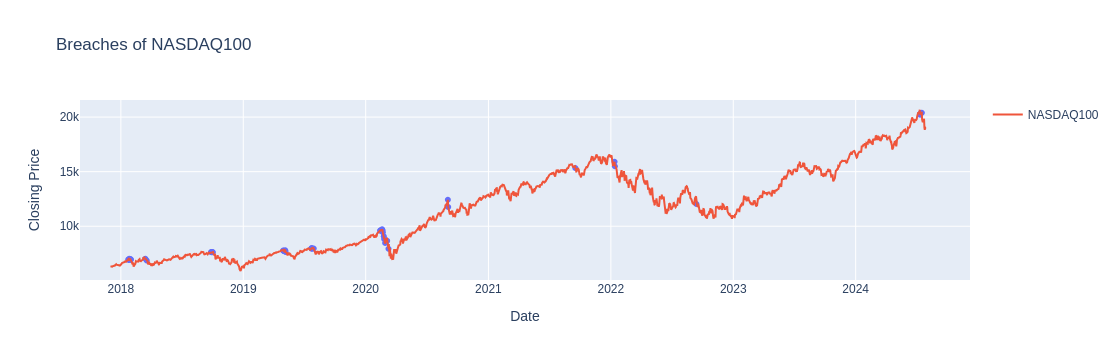

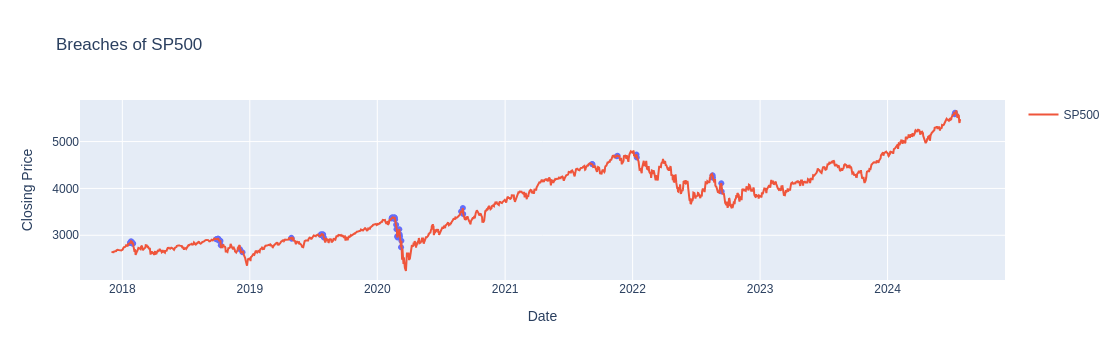

In [32]:
# Task3 (b)
fig = px.scatter(list_breach_NASDAQ100, x = list_breach_NASDAQ100.index, y = 'Closing Price', title = 'Breaches of NASDAQ100')
fig.add_trace(go.Scatter(x = df_NASDAQ100.index, y = df_NASDAQ100['Closing Price'], mode = 'lines', name = 'NASDAQ100' ))
fig.show()

fig = px.scatter(list_breach_SP500, x = list_breach_SP500.index, y = 'Closing Price', title = 'Breaches of SP500')
fig.add_trace(go.Scatter(x = df_SP500.index, y = df_SP500['Closing Price'], mode = 'lines', name = 'SP500' ))
fig.show()